Complete the exercises below For **Assignment #4**.

Use **Markdown** cells for the non-code answers.

In this assignment we will work with the data underlying the *FiveThirtyEight* article ["Higher Rates Of Hate Crimes Are Tied To Income Inequality"](https://fivethirtyeight.com/features/higher-rates-of-hate-crimes-are-tied-to-income-inequality/).

Load the `tidymodels`, `readr`, and `moderndive` packages in the cell below.

In [2]:
install.packages("moderndive")

Installing package into 'C:/Users/ojgos/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)

also installing the dependencies 'lazyeval', 'later', 'snakecase', 'operator.tools', 'crosstalk', 'htmlwidgets', 'promises', 'janitor', 'formula.tools', 'DT'




package 'lazyeval' successfully unpacked and MD5 sums checked
package 'later' successfully unpacked and MD5 sums checked
package 'snakecase' successfully unpacked and MD5 sums checked
package 'operator.tools' successfully unpacked and MD5 sums checked
package 'crosstalk' successfully unpacked and MD5 sums checked
package 'htmlwidgets' successfully unpacked and MD5 sums checked
package 'promises' successfully unpacked and MD5 sums checked
package 'janitor' successfully unpacked and MD5 sums checked
package 'formula.tools' successfully unpacked and MD5 sums checked
package 'DT' successfully unpacked and MD5 sums checked
package 'moderndive' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\ojgos\AppData\Local\Temp\RtmpaQC3ra\downloaded_packages


In [3]:
library(tidymodels)
library(readr)
library(moderndive)

moderndive's `View()` renders a DT::datatable() inline here instead of erroring like `utils::View()`.


Attaching package: 'moderndive'


The following object is masked from 'jupyter:irkernel':

    View


The following object is masked from 'package:utils':

    View




We can read the data from a **CSV file** at the following URL: [http://bit.ly/2ItxYg3](http://bit.ly/2ItxYg3).

Use the `read_csv` function to read the data into our R session. Call the new table `hate_crimes`.

In [4]:
hate_crimes <- read_csv("http://bit.ly/2ItxYg3")

Rows: 51 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): state, median_house_inc, trump_support, unemployment, urbanization
dbl (4): share_pop_metro, hs, hate_crimes, income

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Next, let’s add the high-school degree variable into the mix by creating a scatterplot showing:

- Income on the y-axis (this is the `income` variable)
- Percent of adults 25 or older with a high school degree on the x-axis (this is the `hs` variable)
- The points colored by level of urbanization in a region (this is the variable `urbanization`)


**In addition, add a line of best fit (regression line) for each level of the variable urbanization (one for “low”, one for “high”).**

*Add the regression lines to the plot using the `geom_parallel_slopes` function from the `moderndive` package. This function will draw the regression lines based on fitting a regression model with parallel slopes (i.e., with no interaction between `hs` and `urbanization`).*

Warning message:
"Removed 3 rows containing non-finite outside the scale range
(`stat_parallel_slopes()`)."
Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`)."


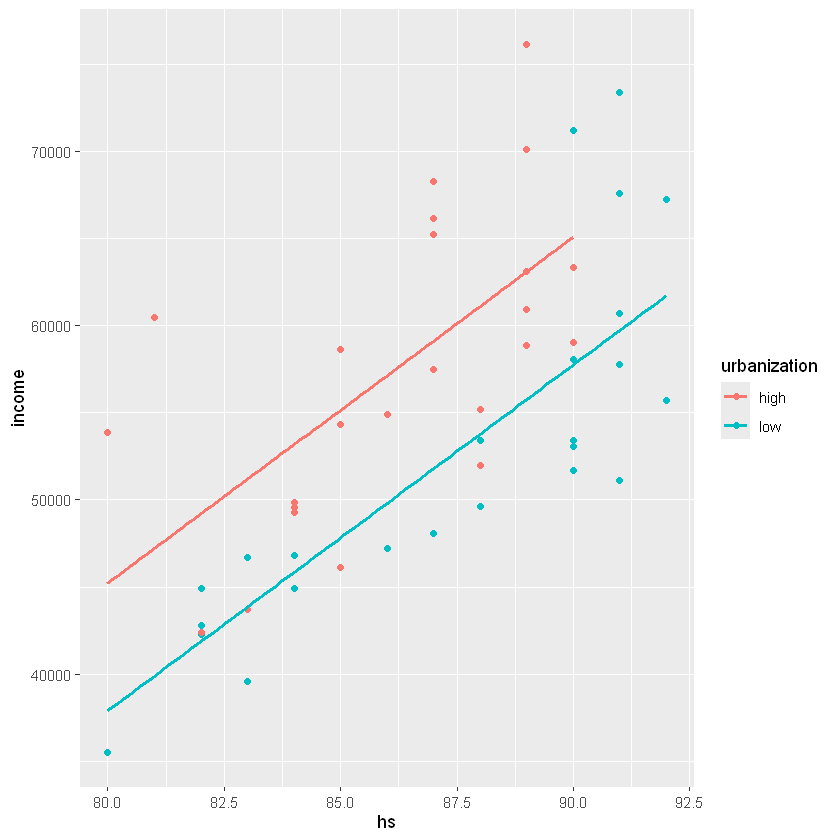

In [5]:
ggplot(hate_crimes, aes(x = hs, y = income, color = urbanization)) +
  geom_point() +
  geom_parallel_slopes(se = FALSE)

❓Which regression line (high urbanization or low urbanization) appears to have the larger intercept?

**Answer:**

The high urbanization regression line appears to have the largest intercept.



Now let’s create a second scatterplot using the same variables, but this time draw the regression lines using `geom_smooth(method = "lm")`, which will allow for separate, non-parallel slopes for each urbanization group. 

**Code your scatter plot in the cell below.**

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 3 rows containing non-finite outside the scale range (`stat_smooth()`)."
Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`)."


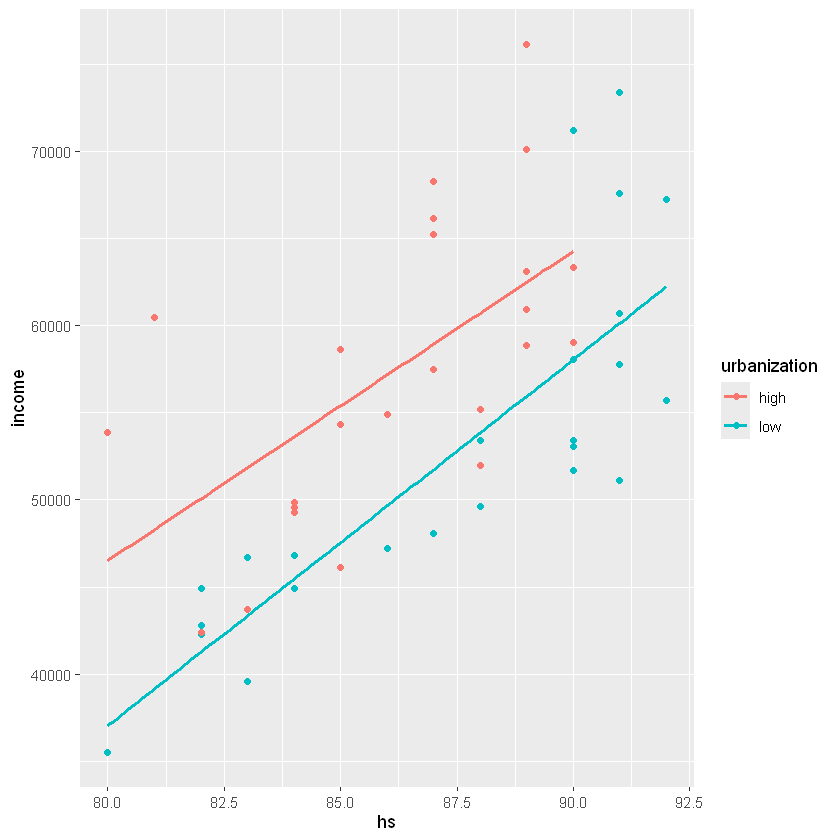

In [6]:
ggplot(hate_crimes, aes(x = hs, y = income, color = urbanization)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE)

❓Based on visually comparing the two models shown above, do you think it would be best to run a “parallel slopes” model (i.e. a model that estimates one shared slope for the two levels of urbanization), or a more complex “interaction model” (i.e. a model that estimates a separate slope for the two levels of urbanization)?

**Answer:**

A parallel slopes model is best because the two regression lines in the interaction plot are nearly parallel. Estimating separate slopes adds unnecessary complexity without improving how well the model describes the relationship.



Fit the following two regression models that examine the relationship between household `income` (as response variable), and high-school education (`hs`) and `urbanization` as explanatory variables:

1. A parallel slopes model (i.e., no interaction between `hs` and `urbanization`). ❗️Save the data recipe and model under the variables `ps_rec` and `ps_mod`, respectively. 
1. A non-parallel slopes model (i.e., allow `hs` and `urbanization` to interact in your model). ❗️Save the data recipe and model under the variable: `nps_rec` and `nps_mod`, respectively.

**Code you your models in the cell below.**

In [8]:
ps_rec <- recipe(income ~ hs + urbanization, data = hate_crimes) |> 
    step_naomit(everything()) |>   
    step_dummy(urbanization) |>    
    prep()                         

mod <- linear_reg() |> set_engine('lm')

ps_mod <- mod |> fit(income ~ ., juice(ps_rec))

In [9]:
# non-parallel slopes model

# ❗️ you can use most of the code above, just add step_interact(~ starts_with("urbanization"):hs) to the recipe and
#    switch the variable names...

nps_rec <- recipe(income ~ hs + urbanization, data = hate_crimes) |> 
    step_naomit(everything()) |>   
    step_dummy(urbanization) |> 
    step_interact(~ starts_with("urbanization"):hs) |> 
    prep()                         

nps_mod <- mod |> fit(income ~ ., juice(nps_rec))

The following code creates a table of your model predictions over the training data. Calculate the [coefficient of determination](https://en.wikipedia.org/wiki/Coefficient_of_determination) (R<sup>2</sup>) for each model:

```r
rbind(
    augment(ps_mod, juice(ps_rec)) |> select(income, .pred, .resid) |> mutate(model = "parallel_slopes"),
    augment(nps_mod, juice(nps_rec)) |> select(income, .pred, .resid) |> mutate(model = "interaction")
)
```

1. Group rows by the `model` variable (use the `group_by` function).
1. Calculate the variance of income over the variance of your predictions for each model using the "grouped" data from the step above (use `summarize(r_squared = var(.pred) / var(income))`).

In [10]:
rbind(
    augment(ps_mod, juice(ps_rec)) |> select(income, .pred, .resid) |> mutate(model = "parallel_slopes"),
    augment(nps_mod, juice(nps_rec)) |> select(income, .pred, .resid) |> mutate(model = "interaction")
) |> 
    group_by(model) |> 
    summarize(r_squared = var(.pred) / var(income))

model,r_squared
<chr>,<dbl>
interaction,0.5746731
parallel_slopes,0.5716112


🎶 Note: you can also use the `glance` function with a model as input to find the coefficient of determination.

In [12]:
glance(ps_mod)
glance(nps_mod)

r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.5716112,0.5525717,6325.667,30.02238,5.204241e-09,2,-486.6739,981.3479,988.8327,1800633086,45,48


r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.5746731,0.5456735,6374.244,19.81661,2.814509e-08,3,-486.5018,983.0035,992.3595,1787763166,44,48


❓Compare the adjusted proportion of variance accounted for in each model. Based on this comparison, which model do you prefer? Why? 

**Answer:**

I prefer the parallel slopes model because its adjusted R^2 (approx. 0.553) is slightly higher than that of the interaction model (approx 0.543). The simpler model actually accounts for a larger proportion of variance once penalized for model complexity.

❓Using your preferred model, based on your regression model parameters (and the data visualizations), is `income` greater in states that have lower or higher levels of `urbanization`? By how much?

**Hint:** use the `tidy` function with your model as input to access the parameters in a nice table.

**Answer:**

In [ ]:
tidy(ps_mod)

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-113725.193,23552.9187,-4.828497,1.624694e-05
hs,1986.794,272.9303,7.279490,3.930730e-09
urbanization_low,-7333.326,1857.6592,-3.947616,2.744526e-04


Income is greater in states with higher levels of urbanization. Based on the model parameter for urbanization_low (-7,333.33), states with lower levels of urbanization have an average median income that is $7,333.33 lower than states with higher levels of urbanization.

❓For every one percentage point increase of high-school educated adults in a state (`hs` variable), what is the associated average increase in `income`?

**Answer:**

For every one percentage point increase in high-school educated adults (hs), the associated average increase in income is $1,986.79. 